In [1]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.engine.walk_forward import walk_forward_splits

# Load data
data = load_multiple_tickers(NIFTY_50, "2015-01-01", "2024-12-31")
prices = get_close_prices(data).dropna(axis=1, how="all")

# Generate folds and inspect
print("Walk-forward folds:")
print("-" * 60)
for i, (train, test) in enumerate(walk_forward_splits(prices.index, train_years=5, test_years=1), 1):
    print(f"Fold {i}:") #enumerate--> adds a counter starting at 1 to each item
    print(f"  Train: {train.min().date()} to {train.max().date()} ({len(train)} days)")
    print(f"  Test:  {test.min().date()} to {test.max().date()} ({len(test)} days)")

Loading RELIANCE.NS ...
Cache for RELIANCE.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading TCS.NS ...
Cache for TCS.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading INFY.NS ...
Cache for INFY.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache (2014-01-01 to 2025-12-30)
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache (2014-01-01 to 2025-12-30)
Loading ITC.NS ...
Loading ITC.NS from cache (2014-01-01 to 2025-12-30)
Loading LT.NS ...
Loading LT.NS from cache (2014-01-01 to 2025-12-30)
Loading KOTAKBANK.N

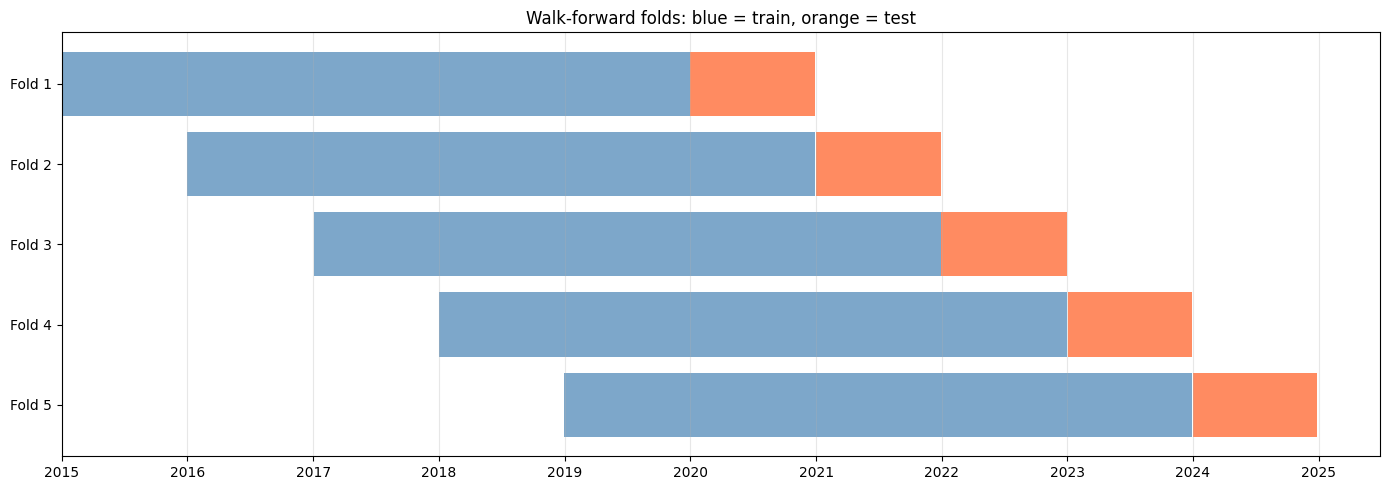

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))

folds = list(walk_forward_splits(prices.index, train_years=5, test_years=1))

for i, (train, test) in enumerate(folds):
    y = -i  # Each fold on a new row
    ax.barh(y, (train.max() - train.min()).days, left=train.min(), color="steelblue", alpha=0.7)
    ax.barh(y, (test.max() - test.min()).days, left=test.min(), color="coral", alpha=0.9)

ax.set_yticks([-i for i in range(len(folds))])
ax.set_yticklabels([f"Fold {i+1}" for i in range(len(folds))])
ax.set_title("Walk-forward folds: blue = train, orange = test")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### Momentum strategy


In [3]:
from backtester.metrics.metrics import daily_returns, performance_report
from backtester.strategies.strategies import momentum_signal
from backtester.engine.costs import apply_costs_to_returns
from backtester.engine.walk_forward import walk_forward_evaluate

# Compute momentum returns over the full period (with costs)
asset_returns = daily_returns(prices)
mom_positions = momentum_signal(prices, lookback_months=12, top_n=5)
shifted = mom_positions.shift(1)
mom_gross_returns = (shifted * asset_returns).sum(axis=1)
mom_net_returns = apply_costs_to_returns(mom_gross_returns, mom_positions)

# In-sample metrics (Week 4 baseline)
in_sample_report = performance_report(mom_net_returns.dropna())

# Out-of-sample via walk-forward
oos_returns = walk_forward_evaluate(mom_net_returns, train_years=5, test_years=1)
oos_report = performance_report(oos_returns.dropna())

# Compare
print(f"{'Metric':<25} {'In-sample':>12} {'Out-of-sample':>15}")
print("-" * 55)
for metric in in_sample_report:
    i = in_sample_report[metric]
    o = oos_report[metric]
    print(f"{metric:<25} {i:>12.4f} {o:>15.4f}")

Metric                       In-sample   Out-of-sample
-------------------------------------------------------
total_return                    3.6597          1.2326
annualized_return               0.1702          0.1779
annualized_volatility           0.2263          0.2635
sharpe_ratio                    0.4870          0.4474
max_drawdown                   -0.4686         -0.4338


### Moving-average crossover strategy


In [5]:
from backtester.strategies.strategies import moving_average_crossover, positions_to_returns

# MA crossover on Reliance
ma_positions = moving_average_crossover(prices["RELIANCE.NS"])
ma_gross_returns = positions_to_returns(ma_positions, asset_returns["RELIANCE.NS"])
ma_net_returns = apply_costs_to_returns(ma_gross_returns, ma_positions)

# In-sample vs out-of-sample
ma_in_sample = performance_report(ma_net_returns.dropna())
ma_oos = performance_report(walk_forward_evaluate(ma_net_returns).dropna())

print(f"\nMA Crossover Reliance (after costs):")
print(f"{'Metric':<25} {'In-sample':>12} {'Out-of-sample':>15}")
print("-" * 55)
for metric in ma_in_sample:
    i = ma_in_sample[metric]
    o = ma_oos[metric]
    print(f"{metric:<25} {i:>12.4f} {o:>15.4f}")


MA Crossover Reliance (after costs):
Metric                       In-sample   Out-of-sample
-------------------------------------------------------
total_return                    1.6367         -0.0515
annualized_return               0.1138         -0.0107
annualized_volatility           0.2499          0.2548
sharpe_ratio                    0.2154         -0.2776
max_drawdown                   -0.4559         -0.4408


### Buy and Hold


In [7]:
from backtester.strategies.strategies import buy_and_hold

bh_positions = buy_and_hold(prices["RELIANCE.NS"])
bh_gross_returns = positions_to_returns(bh_positions, asset_returns["RELIANCE.NS"])
bh_net_returns = apply_costs_to_returns(bh_gross_returns, bh_positions)

bh_in_sample = performance_report(bh_net_returns.dropna())
bh_oos = performance_report(walk_forward_evaluate(bh_net_returns).dropna())

print(f"\nBuy & Hold Reliance (after costs):")
print(f"{'Metric':<25} {'In-sample':>12} {'Out-of-sample':>15}")
print("-" * 55)
for metric in bh_in_sample:
    i = bh_in_sample[metric]
    o = bh_oos[metric]
    print(f"{metric:<25} {i:>12.4f} {o:>15.4f}")


Buy & Hold Reliance (after costs):
Metric                       In-sample   Out-of-sample
-------------------------------------------------------
total_return                    5.3468          0.7956
annualized_return               0.2079          0.1268
annualized_volatility           0.2780          0.2974
sharpe_ratio                    0.5322          0.2245
max_drawdown                   -0.4509         -0.4408


In [ ]:
## unified comparision of three strategies (momentum, MAC, B&H)
import pandas as pd

strategies_data = {
    "Buy & Hold Reliance": bh_net_returns,
    "MA Crossover Reliance": ma_net_returns,
    "Momentum top-5": mom_net_returns,
}

results = {}
for name, net_returns in strategies_data.items():
    in_sample = performance_report(net_returns.dropna())
    oos = performance_report(walk_forward_evaluate(net_returns).dropna())
    
    results[name] = {
        "is_return": in_sample["annualized_return"],
        "oos_return": oos["annualized_return"],
        "is_sharpe": in_sample["sharpe_ratio"],
        "oos_sharpe": oos["sharpe_ratio"],
        "sharpe_decay": in_sample["sharpe_ratio"] - oos["sharpe_ratio"], #difference between in_sample and out_of_sample sharpe ratioes
    }

comparison = pd.DataFrame(results).T.round(4)
print(comparison)
comparison.to_csv("../reports/week5_walk_forward_comparison.csv")
print("\nSaved to reports/week5_walk_forward_comparison.csv")

                       is_return  oos_return  is_sharpe  oos_sharpe  \
Buy & Hold Reliance       0.2079      0.1268     0.5322      0.2245   
MA Crossover Reliance     0.1138     -0.0107     0.2154     -0.2776   
Momentum top-5            0.1702      0.1779     0.4870      0.4474   

                       sharpe_decay  
Buy & Hold Reliance          0.3077  
MA Crossover Reliance        0.4930  
Momentum top-5               0.0396  

Saved to reports/week5_walk_forward_comparison.csv
